# Model Comparison & Statistical Analysis

**Objective:** Compare the trained classifiers using rigorous statistical tests and ROC analysis to determine whether observed performance differences are statistically significant.

---

### Table of Contents

1. [Setup & Data Loading](#1)
2. [Corrected Resampled Paired t-test](#2)
3. [ROC Curves & ROC Convex Hull (ROCCH)](#3)
4. [Final Conclusions & Model Selection](#4)


<a id='1'></a>
## 1. Setup & Data Loading

Import required libraries, configure the global plotting style, and load the evaluation results saved during the training phase.


In [1]:
import joblib
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.metrics import roc_curve, auc
from scipy.spatial import ConvexHull

from config import RESULTS_DIR

# Global settings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 3)

# Plotting style
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)
FIG_DPI = 120
plt.rcParams.update({
    "figure.dpi": FIG_DPI,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "figure.titlesize": 16,
    "figure.titleweight": "bold",
})

# Load evaluation results from the training phase
main_results = joblib.load(f"{RESULTS_DIR}/cv_evaluation_results.pkl")
baseline_results = joblib.load(f"{RESULTS_DIR}/1r_baseline_results.pkl")

# Combine results from both evaluations
all_results = {**baseline_results, **main_results}
models = list(all_results.keys())
print(f"Models loaded: {models}")


Models loaded: ['1R_Baseline', 'Logistic_Regression', 'KNN', 'Random_Forest', 'SVM']


<a id='2'></a>
## 2. Corrected Resampled Paired t-test

Using the standard Student's t-test on measurements derived from Cross-Validation on a single dataset suffers from **dependent estimates**: because training sets overlap, the true variance is underestimated and the test becomes overly liberal.

To address this issue, we apply the Corrected Resampled t-test (Nadeau & Bengio, 2003), specifically adopting the formulation for Repeated k-fold Cross-Validation proposed by Bouckaert & Frank (2004).

The corrected $t$ statistic is defined as:

$$t = \frac{m_d}{\sqrt{(\frac{1}{K \cdot R} + \frac{n_2}{n_1})\sigma_d^2}}$$

Where:
* **$K×R=100$**: The total number of estimates, derived from our R=10 repeats of a K=10-Fold Cross-Validation. This provides 99 degrees of freedom (K×R−1), significantly increasing the statistical power of the test compared to a single CV run.
* **$n_2 / n_1 = 1/9$**: The ratio between the test set size (10%) and the training set size (90%) in each individual fold split.
* **$m_d$** and **$\sigma_d^2$**: The mean and the sample variance of the differences between the two models' scores across all 100 evaluations.


In [ ]:
def corrected_resampled_ttest(scores_A, scores_B, k=100, n1_ratio=0.9, n2_ratio=0.1):
    differences = np.array(scores_A) - np.array(scores_B)
    m_d = np.mean(differences)
    sigma2_d = np.var(differences, ddof=1)

    # Train/test ratio (n2/n1)
    ratio = n2_ratio / n1_ratio
    denominator = np.sqrt((1 / k + ratio) * sigma2_d)

    # Avoid division by zero in case of zero variance
    if denominator == 0:
        return 0.0, 1.0

    t_stat = m_d / denominator

    # Two-tailed p-value (Student's t, df = k-1 -> 99 degrees of freedom for 100 repeats)
    p_value = stats.t.sf(np.abs(t_stat), df=k - 1) * 2
    return t_stat, p_value


# Pairwise comparisons
ALPHA = [0.05, 0.01]  # Significance levels for annotations
p_values_matrix = pd.DataFrame(index=models, columns=models, dtype=float)
results_table = []

for i in range(len(models)):
    for j in range(i + 1, len(models)):
        model_A, model_B = models[i], models[j]
        scores_A = all_results[model_A]["f1_scores"]
        scores_B = all_results[model_B]["f1_scores"]

        t_stat, p_val = corrected_resampled_ttest(scores_A, scores_B, k=100)

        p_values_matrix.loc[model_A, model_B] = p_val
        p_values_matrix.loc[model_B, model_A] = p_val

        if p_val < ALPHA[1]:
            sig = "** (p < 0.01)"
        elif p_val < ALPHA[0]:
            sig = "*  (p < 0.05)"
        else:
            sig = "ns (p >= 0.05)"

        results_table.append({
            "Model A": model_A,
            "Model B": model_B,
            "Mean F1 A": round(np.mean(scores_A), 4),
            "Mean F1 B": round(np.mean(scores_B), 4),
            "t-statistic": round(t_stat, 3),
            "p-value": round(p_val, 4),
            "Significance": sig,
        })

# Fill diagonal
for model in models:
    p_values_matrix.loc[model, model] = 1.0

# ── Styled summary table
def _sig_style(v):
    if "**" in str(v):
        return "color: #d62728; font-weight: bold"
    if "*" in str(v):
        return "color: #ff7f0e; font-weight: bold"
    return "color: #2ca02c"

summary_df = pd.DataFrame(results_table)
print("Corrected Resampled Paired t-test (F1 Score)")
display(
    summary_df.style
    .format({
        "Mean F1 A": "{:.4f}",
        "Mean F1 B": "{:.4f}",
        "t-statistic": "{:.3f}",
        "p-value": "{:.4f}",
    })
    .map(_sig_style, subset=["Significance"])
    .set_table_styles([
        {"selector": "th", "props": [("background-color", "#3A86FF"), ("color", "white"), ("text-align", "center")]},
        {"selector": "td", "props": [("text-align", "center")]},
    ])
    .hide(axis="index")
)


Corrected Resampled Paired t-test (F1 Score)


Model A,Model B,Mean F1 A,Mean F1 B,t-statistic,p-value,Significance
1R_Baseline,Logistic_Regression,0.8338,0.8740,-3.828,0.0002,** (p < 0.01)
1R_Baseline,KNN,0.8338,0.8779,-3.824,0.0002,** (p < 0.01)
1R_Baseline,Random_Forest,0.8338,0.8772,-4.055,0.0001,** (p < 0.01)
1R_Baseline,SVM,0.8338,0.8823,-4.533,0.0000,** (p < 0.01)
Logistic_Regression,KNN,0.8740,0.8779,-0.456,0.6493,ns (p >= 0.05)
Logistic_Regression,Random_Forest,0.8740,0.8772,-0.429,0.6691,ns (p >= 0.05)
Logistic_Regression,SVM,0.8740,0.8823,-1.066,0.2892,ns (p >= 0.05)
KNN,Random_Forest,0.8779,0.8772,0.107,0.9153,ns (p >= 0.05)
KNN,SVM,0.8779,0.8823,-0.530,0.5972,ns (p >= 0.05)
Random_Forest,SVM,0.8772,0.8823,-0.763,0.4471,ns (p >= 0.05)


### Interpretation

The table above reports the corrected t-statistic and p-value for all pairwise model comparisons based on 10-fold CV F1 scores. Significance levels:

| Symbol | Meaning |
|--------|---------|
| **\*\*** | Significant at $\alpha = 0.01$: strong evidence of a performance difference |
| **\*** | Significant at $\alpha = 0.05$: moderate evidence of a performance difference |
| **ns** | Not significant: insufficient evidence to conclude a meaningful difference |


The Corrected Resampled Paired t-test, utilizing the enhanced statistical power of our 10x10 Repeated Nested CV ($K \cdot R=100$, $df=99$), reveals the following key insights:

1. **Validation of Multivariate Machine Learning:** All four complex models (Logistic Regression, KNN, Random Forest, and SVM) significantly outperform the `1R_Baseline` with high statistical confidence ($p < 0.01$). This formally justifies the implementation and computational cost of complex ML pipelines over simple, single-feature heuristic rules for this dataset.

2. **A Statistical Tie Among Advanced Models:** The most critical finding is the complete lack of statistically significant differences among the advanced classifiers. When comparing Logistic Regression, KNN, Random Forest, and SVM against each other, all p-values are well above the significance threshold ($p > 0.05$). This indicates that the small observed differences in their Mean F1-Scores fall strictly within the natural margin of error of the cross-validation process. The models simply trade minor advantages fold by fold, meaning no single algorithm proves consistently superior to the others on this dataset.

<a id='3'></a>
## 3. ROC Curves & ROC Convex Hull (ROCCH)

Although `1R_Baseline` is a hard/discrete classifier and does not produce continuous probability scores, it can still be represented in ROC space as a **single operating point** (connected to the trivial coordinates $(0,0)$ and $(1,1)$).

Computing the **ROC Convex Hull** identifies the set of non-dominated classifiers: any model whose ROC curve never touches the convex hull (golden line) is sub-optimal regardless of the cost ratio $(C_{FP}$ vs $C_{FN})$.


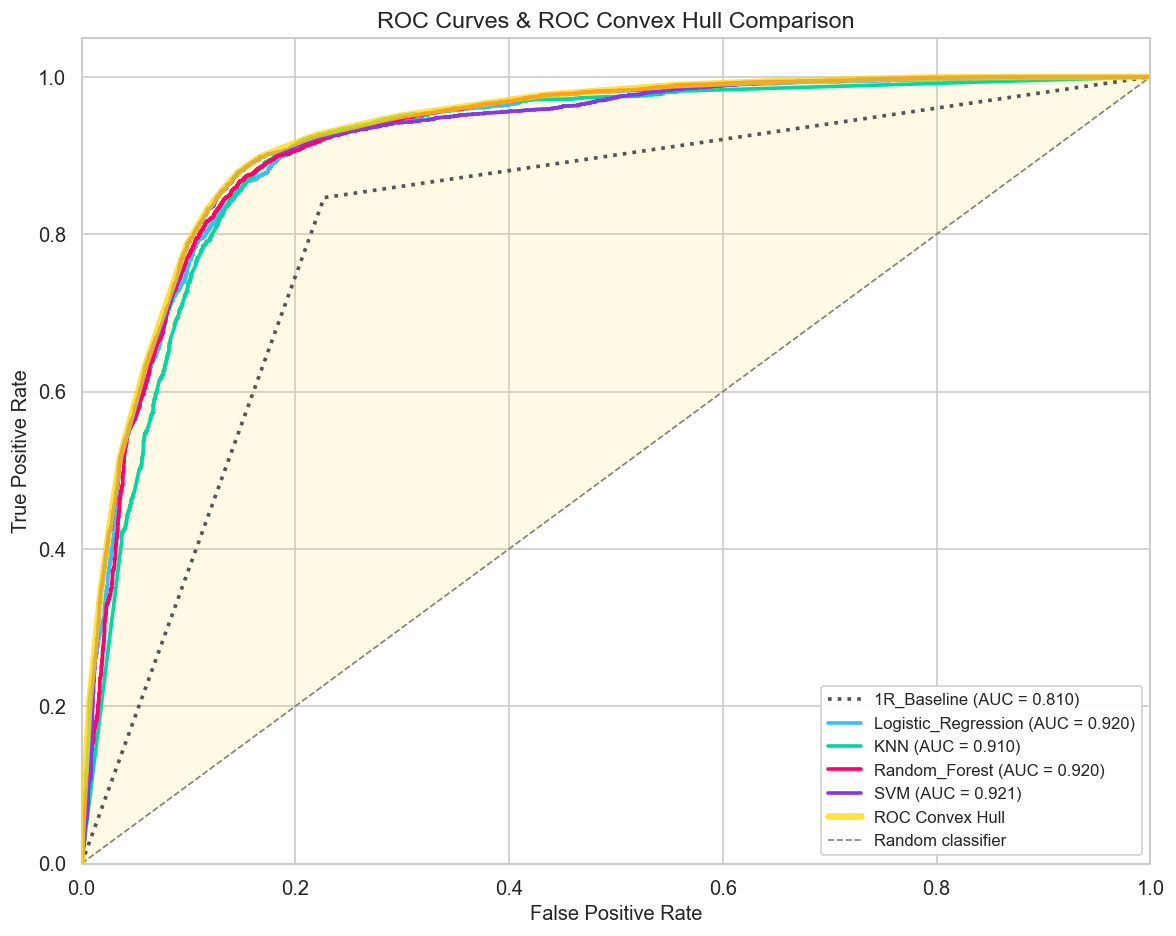

In [4]:
COLORS = {
    "1R_Baseline":         "#555555",
    "Logistic_Regression":  "#3BBEF6",
    "KNN":                  "#06D6A0",
    "Random_Forest":        "#FF006E",
    "SVM":                   "#8338EC",
}
LINESTYLES = {
    "1R_Baseline":         ":",
    "Logistic_Regression":  "-",
    "KNN":                  "-",
    "Random_Forest":        "-",
    "SVM":                   "-",
}

fig, ax = plt.subplots(figsize=(10, 8))

# Accumulate all (FPR, TPR) points for the convex hull
all_fpr = [0.0, 1.0]
all_tpr = [0.0, 1.0]

for model_name in models:
    y_true = np.array(all_results[model_name]["y_true"])
    y_prob = np.array(all_results[model_name]["y_prob"])

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    all_fpr.extend(fpr)
    all_tpr.extend(tpr)

    ax.plot(
        fpr, tpr,
        color=COLORS.get(model_name, "orange"),
        linestyle=LINESTYLES.get(model_name, "-"),
        lw=2.2,
        label=f"{model_name} (AUC = {roc_auc:.3f})",
    )

# ROC Convex Hull 
points = np.column_stack((all_fpr, all_tpr))
hull = ConvexHull(points)
hull_pts = points[hull.vertices]

# Sort by FPR, then keep only the upper (non-decreasing TPR) frontier
# Use lexsort to sort by FPR first, then TPR, ensuring we can easily filter the upper hull
hull_pts = hull_pts[np.lexsort((hull_pts[:, 1], hull_pts[:, 0]))]
upper_hull = [hull_pts[0]]
for pt in hull_pts[1:]:
    if pt[1] >= upper_hull[-1][1]:
        upper_hull.append(pt)
upper_hull = np.array(upper_hull)

ax.plot(
    upper_hull[:, 0], upper_hull[:, 1],
    color="gold", lw=4, alpha=0.75, zorder=5,
    label="ROC Convex Hull",
)
ax.fill_between(
    upper_hull[:, 0], upper_hull[:, 1], upper_hull[:, 0],
    color="gold", alpha=0.10,
)
ax.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="Random classifier")

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves & ROC Convex Hull Comparison")
ax.legend(loc="lower right", fontsize=10, framealpha=0.9)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/roc_convex_hull_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


### Interpretation of ROC Analysis

The ROC curves and the resulting ROC Convex Hull (ROCCH) provide a geometric perspective on model performance across all possible classification thresholds, perfectly complementing our statistical findings:

1. **Convergence of the Leading Models:** The ROC curves of SVM, Random Forest, and Logistic Regression are visually almost indistinguishable across the full FPR range, which is consistent with their nearly identical AUC values (SVM = 0.921, RF = 0.920, LR = 0.920). This suggests that, within the set of models evaluated here, these three classifiers provide essentially equivalent discriminative performance. KNN (AUC = 0.910) follows a similar overall shape but remains slightly below this leading group for most operating points. However, this pattern alone is not sufficient to claim that the predictive ceiling of the dataset has been reached, nor that additional model complexity would necessarily provide no further gain.

2. **ROC Convex Hull:** The ROCCH (gold curve) represents the convex upper envelope of the ROC space generated by the evaluated classifiers. Each point on this boundary corresponds to an operating condition that can be optimal for a specific trade-off between False Positives and False Negatives, making the ROCCH more informative for threshold selection than a single fixed-threshold metric such as F1.

3. **Baseline Validation:** The 1R_Baseline curve (AUC = 0.810), shown as a dotted stepped line, lies clearly below the ROCCH and below the advanced classifiers, highlighting the performance gap between the rule-based baseline and the other models. Its staircase appearance is consistent with a classifier that produces a limited set of discrete score values rather than a smooth range of probabilities. The aggregation over repeated cross-validation folds likely increases the number of visible step changes, but the discrete shape primarily reflects the nature of the underlying score output.

<a id='4'></a>
## 4. Final Conclusions & Model Selection

This section synthesizes the comparative analysis of four advanced Machine Learning algorithms against a heuristic baseline (1R) for Heart Disease prediction. By combining statistical validation (Corrected Resampled t-test) with geometric performance evaluation (ROC Convex Hull), we reach the following definitive conclusions:

1. **The Baseline Validation:** The statistical tests and the ROC analysis definitively prove that all advanced multivariate models (Logistic Regression, KNN, Random Forest, and SVM) significantly outperform the 1R baseline (p < 0.01). This supports the use of multivariate ML approaches over single-rule heuristics, suggesting that interactions among clinical features capture relevant predictive information that cannot be recovered by a one-feature rule alone.

2. **Practical Equivalence of the Leading Models:** Logistic Regression, Random Forest, and SVM show no meaningful separation in overall discriminative performance under the current evaluation protocol. This is also consistent with their nearly identical ROC profiles and AUC values in the figure, where all three lie around 0.920–0.921. KNN also performs well, but its ROC curve remains slightly below this leading group across most operating points, making it better described as competitive rather than co-leading.

3. **The Final Choice:** When several models achieve statistically similar predictive performance, model selection should be guided by deployment criteria rather than accuracy alone. In this context, Logistic Regression emerges as the preferred candidate because it combines competitive discrimination with direct parameter interpretability, simpler implementation, and easier clinical communication than Random Forest or SVM. This does not mean that Logistic Regression is universally superior; rather, it is the most balanced choice here, provided that its calibration and operating threshold are also acceptable for the intended clinical use.